# Raw Sensor Data and Map Exploration

This notebook loads a lidar sample, projects the Lanelet2 map into the ego frame, and visualizes the combined scene.


In [1]:
# Ensure the env_utils package on the repository path is importable.
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "env_utils").exists() and (candidate / "representations").exists():
            return candidate
    raise RuntimeError(f"Could not locate repository root from {start}")

repo_root = find_repo_root(Path.cwd().resolve())
env_utils_src = repo_root / "env_utils" / "src"
if str(env_utils_src) not in sys.path:
    sys.path.append(str(env_utils_src))


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from env_utils import (
    PreparedEnvironment,
    ego_pose_to_matrix,
    prepare_environment,
    transform_point_cloud,
)
from env_utils.lanelet_map import LaneletMapInterface


## Access LiDAR Points


In [3]:
SAMPLE_PATH = repo_root / "representations" / "data" / "demandaer_reading_5733.pkl"
CALIB_ROOT = repo_root / "representations" / "data" / "calib"
LANELET_MAP_PATH = repo_root / "representations" / "data" / "lanelet2_map.osm"

env: PreparedEnvironment = prepare_environment(
    sample_path=SAMPLE_PATH,
    calib_root=CALIB_ROOT,
    lanelet_map_path=LANELET_MAP_PATH,
    sensor_name="lidar_os1",
)

sensor_xyz = env.sensor_points[:, :3]
ego_xyz = env.ego_points[:, :3]
map_xyz = env.map_points[:, :3]
intensity = env.sensor_points[:, 3]
print(f"sensor frame points: {sensor_xyz.shape[0]:,}")
print(f"ego frame points:    {ego_xyz.shape[0]:,}")
print(f"map frame points:    {map_xyz.shape[0]:,}")


sensor frame points: 44,723
ego frame points:    44,723
map frame points:    44,723


## Project Map Geometry to the Ego Frame

The block below uses the Lanelet map interface to gather nearby lanelets and transforms their boundaries into the ego (vehicle) frame.


In [4]:
lanelet_interface: LaneletMapInterface = env.map_interface
ego_pose_matrix = ego_pose_to_matrix(env.ego_pose.position, env.ego_pose.orientation_quat)
assert np.allclose(ego_pose_matrix, env.ego_pose_map, atol=1e-6)

map_to_ego = np.linalg.inv(env.ego_pose_map)
map_points_local = transform_point_cloud(env.map_points, map_to_ego)

query = lanelet_interface.query_lanelets(env.ego_pose, radius=60.0)
lanelet_boundaries_local: list[np.ndarray] = []
for lanelet_id in query.nearby_lanelet_ids:
    lanelet = lanelet_interface.lanelet_map.laneletLayer[lanelet_id]
    _, left, right = lanelet_interface.extract_lanelet_geometry(lanelet, include_z=True)
    if left.size:
        lanelet_boundaries_local.append(transform_point_cloud(left, map_to_ego))
    if right.size:
        lanelet_boundaries_local.append(transform_point_cloud(right, map_to_ego))

print(f"Lanelets in range: {len(query.nearby_lanelet_ids)}")
print(f"Projected boundaries: {len(lanelet_boundaries_local)}")


Lanelets in range: 5
Projected boundaries: 10


## Visualize Raw Point Cloud and Map Overlay

This mirrors the `raw_data.py` output by combining a 3D view of the sensor frame with a 2D ego-frame overlay of the map.


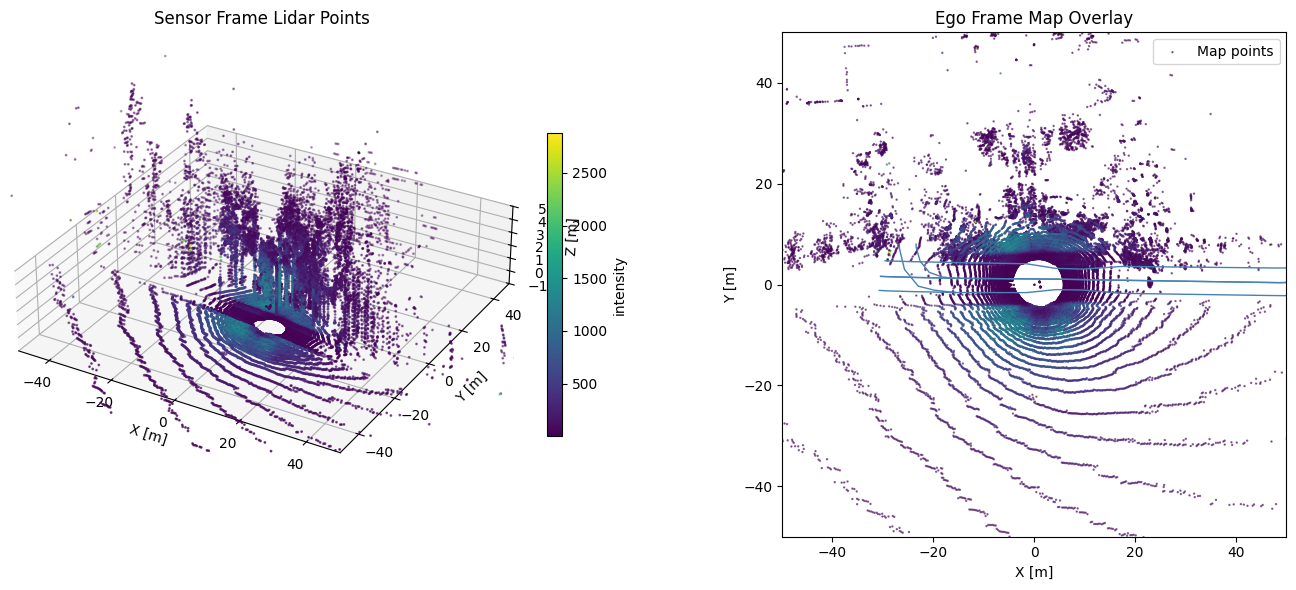

In [5]:
limit_points = 200_000
if sensor_xyz.shape[0] > limit_points:
    rng = np.random.default_rng(seed=0)
    indices = rng.choice(sensor_xyz.shape[0], limit_points, replace=False)
    sensor_vis = sensor_xyz[indices]
    map_vis = map_points_local[indices]
    intensity_vis = intensity[indices]
else:
    sensor_vis = sensor_xyz
    map_vis = map_points_local
    intensity_vis = intensity

fig = plt.figure(figsize=(14, 6))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
scatter = ax3d.scatter(
    sensor_vis[:, 0],
    sensor_vis[:, 1],
    sensor_vis[:, 2],
    c=intensity_vis,
    cmap="viridis",
    s=1.0,
)
ax3d.set_title("Sensor Frame Lidar Points")
ax3d.set_xlabel("X [m]")
ax3d.set_ylabel("Y [m]")
ax3d.set_zlabel("Z [m]")
ax3d.set_box_aspect([1, 1, 0.25])
ax3d.set_xlim(-50, 50)
ax3d.set_ylim(-50, 50)
ax3d.set_zlim(-1, 5)
fig.colorbar(scatter, ax=ax3d, shrink=0.6, label="intensity")

ax2d = fig.add_subplot(1, 2, 2)
ax2d.scatter(
    map_vis[:, 0],
    map_vis[:, 1],
    c=intensity_vis,
    cmap="viridis",
    s=0.5,
    alpha=0.6,
    label="Map points",
)
for boundary in lanelet_boundaries_local:
    ax2d.plot(boundary[:, 0], boundary[:, 1], color="steelblue", linewidth=1.0)
ax2d.set_title("Ego Frame Map Overlay")
ax2d.set_xlabel("X [m]")
ax2d.set_ylabel("Y [m]")
ax2d.set_xlim(-50, 50)
ax2d.set_ylim(-50, 50)
ax2d.set_aspect("equal")
ax2d.legend(loc="upper right")

plt.tight_layout()
plt.show()
